In [17]:

import numpy as np 
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/Training_set.csv
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/Testing_set.csv
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_4378.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_747.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_561.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_345.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_3019.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_2566.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_3156.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_3889.jpg
/kaggle/input/human-action-recognition-har-dataset

1| HAR là gì?

Human Activity Recognition (HAR) – hay còn gọi là nhận dạng hoạt động của con người – là một lĩnh vực nghiên cứu rộng, tập trung vào việc xác định chuyển động hoặc hành động cụ thể của một người dựa trên dữ liệu cảm biến.
Các chuyển động này thường là những hoạt động phổ biến trong đời sống hàng ngày, như đi bộ, nói chuyện, đứng, hoặc ngồi.
*Tại sao HAR lại quan trọng?

Nhận dạng hoạt động của con người đóng vai trò rất quan trọng trong việc hiểu và mô phỏng tương tác giữa người với người, cũng như trong các mối quan hệ xã hội. Vì HAR cung cấp thông tin về danh tính, tính cách và trạng thái tâm lý của một người – những yếu tố khó trích xuất – nên nó trở thành một thách thức lớn trong nghiên cứu. Khả năng của con người trong việc nhận biết hành động của người khác là một trong những chủ đề trọng tâm của các lĩnh vực thị giác máy tính (computer vision) và học máy (machine learning).
Nhờ các nghiên cứu trong lĩnh vực này, nhiều ứng dụng thực tế đã ra đời, bao gồm:

Hệ thống giám sát bằng video,

Giao tiếp người–máy (human-computer interaction),

Robot mô phỏng hành vi con người,

Và các hệ thống nhận dạng đa hoạt động phục vụ phân tích hành vi.

## 2| Importing thư viện

In [18]:
!pip install tensorflow==2.15.0  keras tensorflow-addons==0.23.0


In [19]:
import os
import glob
import random
import numpy as np
import pandas as pd

import tensorflow_addons as tfa
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Activation, Dropout, Flatten, Dense
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from PIL import Image

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, 
    EarlyStopping, 
    ModelCheckpoint
)

import seaborn as sns
import matplotlib.image as img
import matplotlib.pyplot as plt


# 3| Tải dữ liệu
Dữ liệu được lấy từ nguồn https://www.kaggle.com/code/kirollosashraf/human-action-recognition-har.

Là các ảnh tĩnh có số lượng ảnh vừa phải, chứa 15 lớp hoạt động của con người ( 15 activity classes): calling, clapping, cycling, dancing, drinking, eating, fighting, hugging, laughing, listening_to_music, running, sitting, sleeping, texting, using_laptop.

Có 12 600 ảnh cho huấn luyện-train- và 5400 ảnh cho kiểm trả-test.
Mỗi ảnh là một người.



In [20]:
# file training_set.csv(12600) chứa 2 cột 1 là tên file ảnh, 2 là nhãn -classify-
train_data = pd.read_csv("../input/human-action-recognition-har-dataset/Human Action Recognition/Training_set.csv")

In [21]:
# folder train chứa ảnh cho huấn luyện 
train_fol = glob.glob("../input/human-action-recognition-har-dataset/Human Action Recognition/train/*") 

In [22]:
train_data

,filename,label
0,Image_1.jpg,sitting
1,Image_2.jpg,using_laptop
2,Image_3.jpg,hugging
3,Image_4.jpg,sleeping
4,Image_5.jpg,using_laptop
...,...,...
12595,Image_12596.jpg,sitting
12596,Image_12597.jpg,clapping
12597,Image_12598.jpg,sitting
12598,Image_12599.jpg,dancing


Qua việc đếm số lượng => dataset này cân bằng giữa các lớp

In [23]:
train_data.label.value_counts()

label
sitting               840
using_laptop          840
hugging               840
sleeping              840
drinking              840
clapping              840
dancing               840
cycling               840
calling               840
laughing              840
eating                840
fighting              840
listening_to_music    840
running               840
texting               840
Name: count, dtype: int64

In [24]:
import plotly.express as px
HAR = train_data.label.value_counts()
fig = px.pie(train_data, values=HAR.values, names=HAR.index, title='Distribution of Human Activity')
fig.show()

In [25]:
# tên ảnh
filename = train_data['filename']
# lable hoạt động
situation = train_data['label']

In [26]:
filename

0            Image_1.jpg
1            Image_2.jpg
2            Image_3.jpg
3            Image_4.jpg
4            Image_5.jpg
              ...       
12595    Image_12596.jpg
12596    Image_12597.jpg
12597    Image_12598.jpg
12598    Image_12599.jpg
12599    Image_12600.jpg
Name: filename, Length: 12600, dtype: object

# 4| Xây dựng hàm để hiện thị ảnh ngẫu nhiên

In [27]:
def displaying_random_images():
    num = random.randint(1,10000)
    imgg = "Image_{}.jpg".format(num)
    train = "../input/human-action-recognition-har-dataset/Human Action Recognition/train/"
    if os.path.exists(train+imgg):
        testImage = img.imread(train+imgg)
        plt.imshow(testImage)
        plt.title("{}".format(train_data.loc[train_data['filename'] == "{}".format(imgg), 'label'].item()))

    else:
        #print(train+img)
        print("File Path not found \nSkipping the file!!")

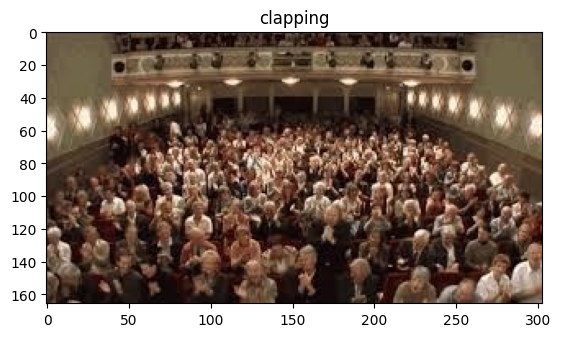

In [28]:
displaying_random_images()

# 5. tiền xử lí dữ liệu sử dụng IMAGEDATAGENERATOR ( Khống tốn RAM)

Resize kích thước ảnh về một kích thước (160*160)

ColorJitter:  Tăng độ đa dạng dữ liệu — mô phỏng điều kiện ánh sáng, màu sắc khác nhau.

Horizontal Flip: Giúp mô hình học được tính “bất biến theo hướng” (orientation invariance) — ví dụ người đi trái hay đi phải đều là “đi bộ”.

Normalize: Chuẩn hóa phân phối pixel để mô hình học ổn định hơn bằng cách trừ đi giá trị trung bình và chia cho độ lệch chuẩn của từng kênh màu, giúp dữ liệu đầu vào có trung bình ≈ 0 và độ lệch chuẩn ≈ 1, giúp mô hình học ổn định hơn.”.

In [29]:
#Tạo generator với augment 
# EfficientNet pretrained ImageNet cần input [-1,1] với mean/std cụ thể
from tensorflow.keras.applications.efficientnet import preprocess_input
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,# tự động lật ngang trong quá trình train( Ngẫu nhiên)
    validation_split=0.2
)
# Đường dẫn thư mục ảnh
train_folder = "../input/human-action-recognition-har-dataset/Human Action Recognition/train"

Chuyển đổi label từ kí tự sang số sử dụng onehot vecto vì model sử dụng được huấn luyện theo dạng phân loại nhiều lớp: 

    label đang là string nên cần sử dụng LabelEncode để chuyển sang số và từ đó sử dụng onehot.

    Sử dụng LableEncode để có thể lưu và dùng chuyển đổi ngược về string trong quá trình regconition

Quá trình chia dữ liệu thành Tran và validation (8:2)

In [30]:
# TRAIN GENERATOR
train_gen = datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_folder,
    x_col="filename",
    y_col="label",
    target_size=(160, 160),
    batch_size=32,
    # tự động mã hóa về dạng số và chuyển đổi thảnh one-hot vector
    # tương tự quá trình mình thực hiện LabelEnCoder  rồi one-hot vector
    class_mode='categorical', 
    subset='training',
    shuffle=True,
    seed=42
)

# VALIDATION GENERATOR
val_gen = datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_folder,
    x_col="filename",
    y_col="label",
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
import joblib
# Lưu tên lớp để dự đoán sau (thay cho LabelEncoder)
class_names = list(train_gen.class_indices.keys())
joblib.dump(class_names, "class_names.pkl")
print("Class names:", class_names)
print(f"Train samples: {train_gen.samples}")
print(f"Val samples: {val_gen.samples}")

Found 10080 validated image filenames belonging to 15 classes.
Found 2520 validated image filenames belonging to 15 classes.
Class names: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Train samples: 10080
Val samples: 2520


In [31]:
# Xem 1 batch từ train_gen
x_batch, y_batch = next(train_gen)

print("Kích thước ảnh (batch):", x_batch.shape)     # (32, 160, 160, 3)
print("Kích thước nhãn (batch):", y_batch.shape)     # (32, 15) ← ONE-HOT!
print("Nhãn đầu tiên (one-hot):", y_batch[0])
print("Chỉ số lớp có giá trị 1:", np.argmax(y_batch[0]))
print("Tên hành động:", class_names[np.argmax(y_batch[0])])

Kích thước ảnh (batch): (32, 160, 160, 3)
Kích thước nhãn (batch): (32, 15)
Nhãn đầu tiên (one-hot): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Chỉ số lớp có giá trị 1: 3
Tên hành động: dancing


# 6| Xây dựng kiến trúc model huấn luyện và đánh giá


EfficientNet là một họ mô hình mạng nơ-ron tích chập (CNN) được giới thiệu năm 2019 bởi nhóm nghiên cứu của Google AI (Mingxing Tan & Quoc V. Le) trong bài báo “EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks”.

Khác với các mô hình truyền thống như ResNet hay VGG, EfficientNet sử dụng phương pháp Compound Scaling — một kỹ thuật mở rộng đồng thời chiều sâu (depth), chiều rộng (width) và độ phân giải (resolution) của mạng theo một hệ số chung, giúp tối ưu hiệu quả giữa độ chính xác và tốc độ.

sử dụng mô hình EfficientNetB7 (phiên bản lớn nhất của EfficientNet) được sử dụng.
Mô hình đã được huấn luyện sẵn (pretrained) trên bộ dữ liệu ImageNet và được fine-tune lại để phù hợp với tập dữ liệu hành động con người (Human Action Recognition).

Việc fine-tune giúp mô hình tận dụng được đặc trưng hình ảnh tổng quát đã học được từ ImageNet (như biên dạng, màu sắc, cấu trúc vật thể), đồng thời thích nghi với các đặc trưng riêng của bộ dữ liệu mới.


Fine tune model 

Bước 1: Train giai đoạn 1 (freeze)

In [33]:
num_classes = len(class_names)

# --- Cấu hình EfficientNetB1 pretrained nếu đủ RAM khuyến khích dùng  EfficientNetB7 ---
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,          # Bỏ phần fully-connected gốc
    input_shape=(160, 160, 3),  # Kích thước ảnh
    pooling="avg",              # Global Average Pooling
    weights="imagenet"          # Dùng trọng số pretrained ImageNet
)

# Đóng băng các layer pretrained (chưa fine-tune)
for layer in base_model.layers:
    layer.trainable = False

# --- Xây mô hình hoàn chỉnh ---
efficientnet_model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation="relu"),
    Dropout(0.5),  # Thêm để chống overfit
    Dense(num_classes, activation="softmax")   
])


In [34]:
# --- Cấu hình optimizer, loss, metrics ---
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Giảm Learning Rate nếu sau 3 epoch val_accuaracy không cải thiện
callbacks = [
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # Dừng nếu sau 8 epoch val_accuaracy không cải thiện
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Nếu model có độ chính xác cao nhất
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [35]:
# Xem cấu trúc model
efficientnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb3 (Functional  (None, 1536)              10783535  
 )                                                               
                                                                 
 flatten_2 (Flatten)         (None, 1536)              0         
                                                                 
 dense_2 (Dense)             (None, 512)               786944    
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 15)                7695      
                                                                 
Total params: 11578174 (44.17 MB)
Trainable params: 794639 (3.03 MB)
Non-trainable params: 10783535 (41.14 MB)
___________

Huấn luyện

In [36]:
# Huấn luyện model giai đoạn 1
EPOCHS = 10
history_stage1 = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
315/315 [==============================] - ETA: 0s - loss: 1.9730 - accuracy: 0.3924
Epoch 1: val_accuracy improved from -inf to 0.59603, saving model to best_model.keras
315/315 [==============================] - 468s 1s/step - loss: 1.9730 - accuracy: 0.3924 - val_loss: 1.4020 - val_accuracy: 0.5960 - lr: 1.0000e-04
Epoch 2/10
315/315 [==============================] - ETA: 0s - loss: 1.4120 - accuracy: 0.5573
Epoch 2: val_accuracy improved from 0.59603 to 0.63294, saving model to best_model.keras
315/315 [==============================] - 425s 1s/step - loss: 1.4120 - accuracy: 0.5573 - val_loss: 1.2083 - val_accuracy: 0.6329 - lr: 1.0000e-04
Epoch 3/10
315/315 [==============================] - ETA: 0s - loss: 1.2583 - accuracy: 0.6040
Epoch 3: val_accuracy improved from 0.63294 to 0.64802, saving model to best_model.keras
315/315 [==============================] - 433s 1s/step - loss: 1.2583 - accuracy: 0.6040 - val_loss: 1.1509 - val_accuracy: 0.6480 - lr: 1.0000e-04
E

Bước 2: Fine-tune EfficientNetB1 (mở khóa các layer cuối)

In [37]:
# Mở fine-tune cho các layer cuối cùng của EfficientNetB1
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Biên dịch lại model với learning rate thấp hơn
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Epoch 1/30
315/315 [==============================] - ETA: 0s - loss: 1.1111 - accuracy: 0.6510
Epoch 1: val_accuracy improved from 0.67302 to 0.67341, saving model to best_model.keras
315/315 [==============================] - 494s 2s/step - loss: 1.1111 - accuracy: 0.6510 - val_loss: 1.0312 - val_accuracy: 0.6734 - lr: 1.0000e-04
Epoch 2/30
315/315 [==============================] - ETA: 0s - loss: 0.9092 - accuracy: 0.7118
Epoch 2: val_accuracy improved from 0.67341 to 0.68373, saving model to best_model.keras
315/315 [==============================] - 483s 2s/step - loss: 0.9092 - accuracy: 0.7118 - val_loss: 0.9904 - val_accuracy: 0.6837 - lr: 1.0000e-04
Epoch 3/30
315/315 [==============================] - ETA: 0s - loss: 0.8116 - accuracy: 0.7362
Epoch 3: val_accuracy improved from 0.68373 to 0.69127, saving model to best_model.keras
315/315 [==============================] - 415s 1s/step - loss: 0.8116 - accuracy: 0.7362 - val_loss: 0.9579 - val_accuracy: 0.6913 - lr: 1.0000e-0

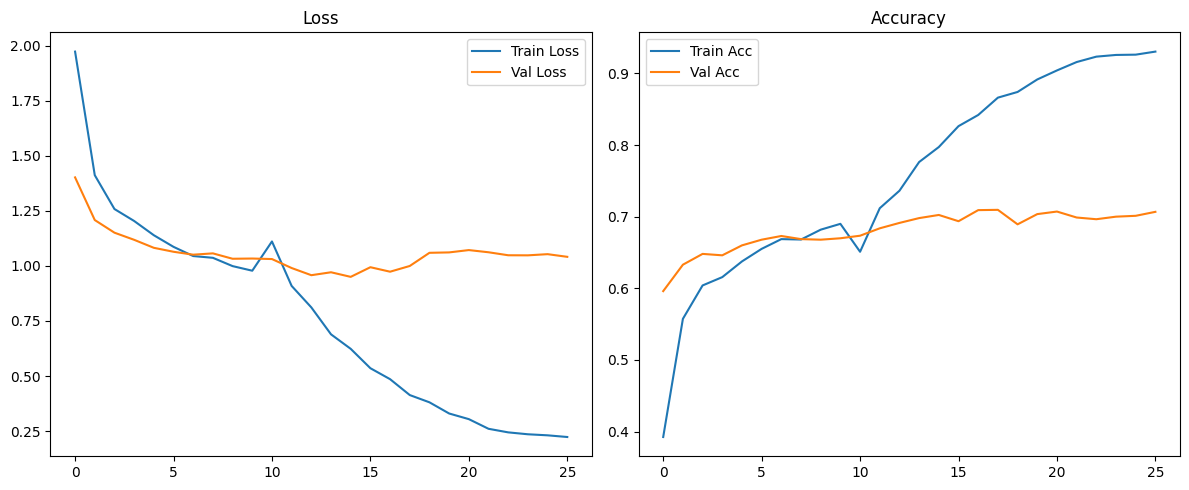

In [38]:
history_stage2 = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,             
    callbacks=callbacks,
    verbose=1
)
# Ghép lịch sử training lại
history_combined = {
    'loss': history_stage1.history['loss'] + history_stage2.history['loss'],
    'val_loss': history_stage1.history['val_loss'] + history_stage2.history['val_loss'],
    'accuracy': history_stage1.history['accuracy'] + history_stage2.history['accuracy'],
    'val_accuracy': history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
}

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_combined['loss'], label='Train Loss')
plt.plot(history_combined['val_loss'], label='Val Loss')
plt.legend(); 
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history_combined['accuracy'], label='Train Acc')
plt.plot(history_combined['val_accuracy'], label='Val Acc')
plt.legend(); 
plt.title('Accuracy')
plt.tight_layout(); 
plt.show()

In [ ]:

# # Trực quan hóa quá trình train
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.legend()
# plt.title('Loss')

# plt.subplot(1, 2, 2)
# plt.plot(history.history['accuracy'], label='Train Acc')
# plt.plot(history.history['val_accuracy'], label='Val Acc')
# plt.legend()
# plt.title('Accuracy')
# plt.tight_layout()
# plt.savefig('training_history.png')
# plt.show()

# print(f"Best Val Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")